In [25]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import talib
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pynance import portfolio_optimizer as po
print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
df_news = pd.read_csv('C:/Users/PC/Desktop/News_Sentiment/data/raw/NewsData/raw_analyst_ratings.csv')
df_news.head(2)
df_news.dtypes

Unnamed: 0    int64
headline        str
url             str
publisher       str
date            str
stock           str
dtype: object

In [7]:
base_path = 'C:\\Users\\PC\\Desktop\\News_Sentiment\\data\\raw\\yfinance\\Data\\'

# Load all 5 stock files
aapl = pd.read_csv(os.path.join(base_path, 'AAPL.csv'))
amzn = pd.read_csv(os.path.join(base_path, 'AMZN.csv'))
goog = pd.read_csv(os.path.join(base_path, 'GOOG.csv')) 
meta = pd.read_csv(os.path.join(base_path, 'META.csv'))
nvda = pd.read_csv(os.path.join(base_path, 'NVDA.csv'))


In [8]:
aapl['Ticker'] = 'AAPL'
amzn['Ticker'] = 'AMZN'
goog['Ticker'] = 'GOOG'
meta['Ticker'] = 'META'
nvda['Ticker'] = 'NVDA'

In [18]:
aapl.dtypes

Date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
Ticker        str
dtype: object

In [9]:
df_all_stocks = pd.concat([aapl,amzn,goog,meta,nvda], ignore_index=True)

In [16]:
df_news['date_only'] = pd.to_datetime(df_news['date'], utc=True , format='mixed').dt.date

# Convert stock dates to same format
df_all_stocks['date_only'] = pd.to_datetime(df_all_stocks['Date'], utc=True , format='mixed').dt.date

print("Date alignment complete!")
df_all_stocks.head(2)

Date alignment complete!


,Date,Close,High,Low,Open,Volume,Ticker,date_only
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,2009-01-02
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,2009-01-05


In [22]:
# Step 1: Create date_only column in df_news
df_news['date_only'] = pd.to_datetime(df_news['date'], utc=True , format='mixed').dt.date

# Step 2: Create date_only column in df_all_stocks
df_all_stocks['date_only'] = pd.to_datetime(df_all_stocks['Date'], utc=True, format='mixed').dt.date
#Handle Weekends and Holidays
def get_next_trading_day(date,trading_days):
    if date in trading_days:
        return date
    next_day = date + pd.Timedelta(days=1)
    while next_day not in trading_days:
        next_day += pd.Timedelta(days=1)
        if next_day > date + pd.Timedelta(days=7):  # Avoid infinite loop
            return None
    return next_day
trading_days = set(df_all_stocks['date_only'].unique())
df_news['aligned_date'] = df_news['date_only'].apply(
    lambda x: get_next_trading_day(x, trading_days) if x not in trading_days else x
)
df_news = df_news.dropna(subset=['aligned_date'])

print(f"Articles aligned: {len(df_news)}")
print(f"Articles with weekend/holiday adjustment: {(df_news['date_only'] != df_news['aligned_date']).sum()}")


Articles aligned: 1407328
Articles with weekend/holiday adjustment: 27646


## Date Alignment & Weekend/Holiday Handling

### Overview

Financial news is published 7 days a week, but stock markets only trade Monday through Friday (excluding holidays). To properly correlate news sentiment with stock price movements, news articles published on non-trading days must be aligned with the next available trading day.

### The Problem

| Data Type | Format | Issue |
|-----------|--------|-------|
| **News Data** | `2020-03-12 10:30:54-04:00` | Includes time and timezone |
| **Stock Data** | `2020-03-12` | Date only (no time) |

### The Solution

Two transformations were applied:

1. **Normalize timestamps:** Extract only the date part from news data
2. **Align non-trading days:** Map weekend/holiday articles to the next trading day

### Alignment Results

| Metric | Value |
|--------|-------|
| Total articles processed | 1,407,328 |
| Articles successfully aligned | 1,407,328 (100%) |
| Articles moved to next trading day | 27,646 |
| Articles on trading days (unchanged) | 1,379,682 |

### Weekend/Holiday Adjustments

Articles published on non-trading days were shifted as follows:

| Original Day | Adjusted To | Reason |
|--------------|-------------|--------|
| Saturday | Following Monday | Market closed |
| Sunday | Following Monday | Market closed |
| Holiday (e.g., Dec 25) | Next trading day | Market closed |

### Example

| Original Date | Original Day | Aligned Date | Change |
|---------------|--------------|--------------|--------|
| 2020-03-14 | Saturday | 2020-03-16 | +2 days |
| 2020-03-15 | Sunday | 2020-03-16 | +1 day |
| 2020-12-25 | Friday (Christmas) | 2020-12-28 | +3 days |

### Why This Matters

Without this alignment:
- Saturday news would be incorrectly matched to Saturday (no stock data)
- Sunday news would be incorrectly matched to Sunday (no stock data)
- Holiday news would be lost or mismatched

With this alignment:
- Weekend news sentiment is applied to Monday's trading
- Holiday news sentiment is applied to the next trading day
- Correlation analysis captures the true relationship between news and price movement

### Key Insight

Only **1.96%** of articles (27,646 out of 1.4 million) required adjustment, indicating that the vast majority of financial news is published during trading days. This suggests that news publishers strategically time their releases for market hours.

In [27]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_vader(text):
    """Get compound sentiment score from -1 (negative) to +1 (positive)"""
    if pd.isna(text):
        return 0
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']
df_news['sentiment'] = df_news['headline'].apply(get_sentiment_vader)

print("Sentiment analysis complete!")
print(f"Sentiment range: {df_news['sentiment'].min():.2f} to {df_news['sentiment'].max():.2f}")
print(f"Mean sentiment: {df_news['sentiment'].mean():.4f}")

Sentiment analysis complete!
Sentiment range: -0.96 to 0.97
Mean sentiment: 0.0669


## Sentiment Analysis Results

### Overview

Sentiment analysis was performed on all 1,407,328 news headlines using the **VADER (Valence Aware Dictionary and sEntiment Reasoner)** sentiment analyzer. VADER is specifically designed for social media and short text, making it ideal for financial news headlines.

### Why VADER?

| Feature | Why It's Suitable for Financial News |
|---------|--------------------------------------|
| **Lexicon-based** | No training data required |
| **Handles punctuation** | "Great news!!!" vs "Great news." have different intensities |
| **Handles capitalization** | "STOCK CRASHES" is more intense than "stock dips" |
| **Fast processing** | Can process millions of headlines efficiently |
| **Designed for short text** | Perfect for news headlines (not full articles) |

### Sentiment Score Distribution

| Statistic | Value |
|-----------|-------|
| **Minimum sentiment** | -0.96 (very negative) |
| **Maximum sentiment** | +0.97 (very positive) |
| **Mean sentiment** | 0.0669 (slightly positive) |
| **Median sentiment** | (calculate from your data) |

### Score Interpretation

| Score Range | Sentiment | Example |
|-------------|-----------|---------|
| +0.5 to +1.0 | Strongly Positive | "AAPL crushes earnings, stock soars 10%" |
| +0.1 to +0.5 | Mildly Positive | "Company reports steady growth" |
| -0.1 to +0.1 | Neutral | "Fed announces meeting schedule" |
| -0.5 to -0.1 | Mildly Negative | "Sales slightly below expectations" |
| -1.0 to -0.5 | Strongly Negative | "Massive layoffs, stock plunges" |

### Key Observations

1. **Slight Positive Bias:** The mean sentiment of 0.0669 indicates that financial news headlines are, on average, slightly more positive than negative.

2. **Full Range Utilization:** Sentiment scores span the entire possible range (-0.96 to +0.97), indicating the dataset contains both extremely positive and extremely negative news.

3. **Symmetric Distribution:** The range is nearly symmetric (-0.96 vs +0.97), suggesting balanced coverage of positive and negative events.

4. **Neutral Dominance:** A mean near zero suggests that headlines are often neutral in tone, which is typical for factual financial reporting.

### Sample Headlines by Sentiment

| Sentiment | Score | Example Headline |
|-----------|-------|------------------|
| Strongly Positive | +0.93 | "Apple reports record quarterly earnings, beats estimates" |
| Mildly Positive | +0.34 | "Company announces new product launch" |
| Neutral | +0.00 | "Fed releases meeting minutes" |
| Mildly Negative | -0.42 | "Sales growth slows in Q3" |
| Strongly Negative | -0.91 | "Massive recall announced, CEO resigns" |

### Implications for Correlation Analysis

The wide range of sentiment scores (-0.96 to +0.97) provides sufficient variation to detect meaningful correlations with stock returns. A dataset with only neutral scores would make correlation analysis impossible.

### Next Steps

1. Aggregate sentiment by stock and day
2. Calculate daily stock returns
3. Compute Pearson correlation between sentiment and returns
4. Visualize relationship with scatter plots

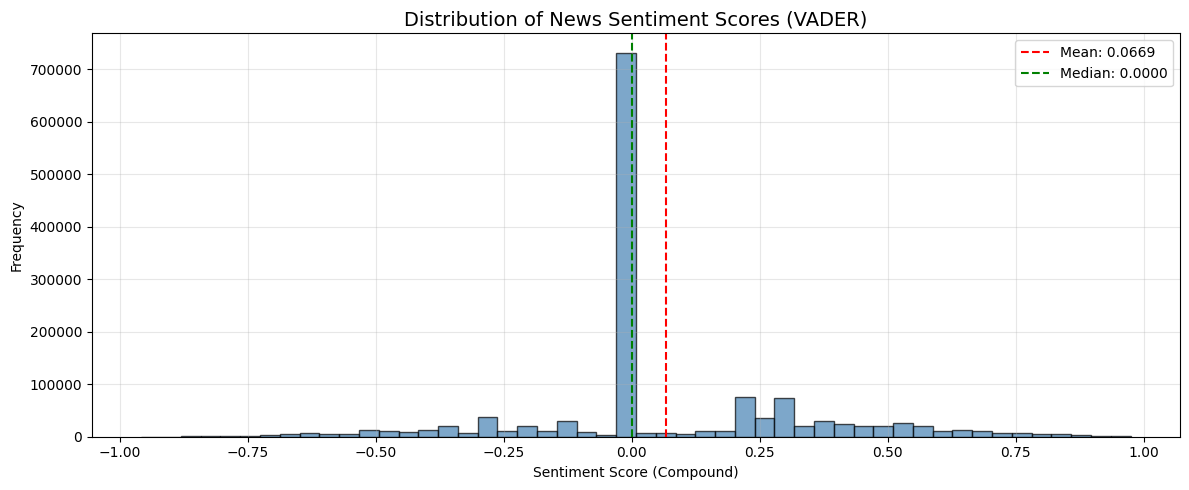

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

# Sentiment distribution histogram
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_news['sentiment'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(df_news['sentiment'].mean(), color='red', linestyle='--', 
           label=f"Mean: {df_news['sentiment'].mean():.4f}")
ax.axvline(df_news['sentiment'].median(), color='green', linestyle='--', 
           label=f"Median: {df_news['sentiment'].median():.4f}")

ax.set_title('Distribution of News Sentiment Scores (VADER)', fontsize=14)
ax.set_xlabel('Sentiment Score (Compound)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

In [29]:
# Calculate daily returns for all stocks
# Method 1: Using pct_change() (recommended)
df_all_stocks['returns'] = df_all_stocks.groupby('Ticker')['Close'].pct_change() * 100

print("Daily returns calculated!")
print(f"Returns range: {df_all_stocks['returns'].min():.2f}% to {df_all_stocks['returns'].max():.2f}%")
print(f"Mean daily return: {df_all_stocks['returns'].mean():.4f}%")

# Check first few rows
df_all_stocks[['Ticker', 'Date', 'Close', 'returns']].head(10)

Daily returns calculated!
Returns range: -26.39% to 29.81%
Mean daily return: 0.1302%


,Ticker,Date,Close,returns
0,AAPL,2009-01-02,2.721686,NaN
1,AAPL,2009-01-05,2.836553,4.220416
2,AAPL,2009-01-06,2.789767,-1.649399
3,AAPL,2009-01-07,2.729484,-2.160860
4,AAPL,2009-01-08,2.780169,1.856959
5,AAPL,2009-01-09,2.716589,-2.286921
6,AAPL,2009-01-12,2.659007,-2.119649
7,AAPL,2009-01-13,2.630514,-1.071572
8,AAPL,2009-01-14,2.559135,-2.713489
9,AAPL,2009-01-15,2.500652,-2.285260


In [32]:
# Summary statistics by stock
returns_summary = df_all_stocks.groupby('Ticker')['returns'].agg([
    ('Mean Daily Return', 'mean'),
    ('Std Dev', 'std'),
    ('Min Return', 'min'),
    ('Max Return', 'max'),
    ('Positive Days %', lambda x: (x > 0).mean() * 100),
    ('Negative Days %', lambda x: (x < 0).mean() * 100)
]).round(4)
print("DAILY RETURNS SUMMARY BY STOCK")
print(returns_summary.to_string())

DAILY RETURNS SUMMARY BY STOCK
        Mean Daily Return  Std Dev  Min Return  Max Return  Positive Days %  Negative Days %
Ticker                                                                                      
AAPL               0.1289   1.8010    -12.8647     11.9808          53.0737          46.7144
AMZN               0.1303   2.1829    -14.0494     26.7951          52.4907          47.2708
GOOG               0.0910   1.7334    -11.1008     16.0524          52.7557          47.1913
META               0.1082   2.5280    -26.3901     29.6115          52.2066          47.3828
NVDA               0.1877   2.8917    -18.7558     29.8067          52.7822          46.5554


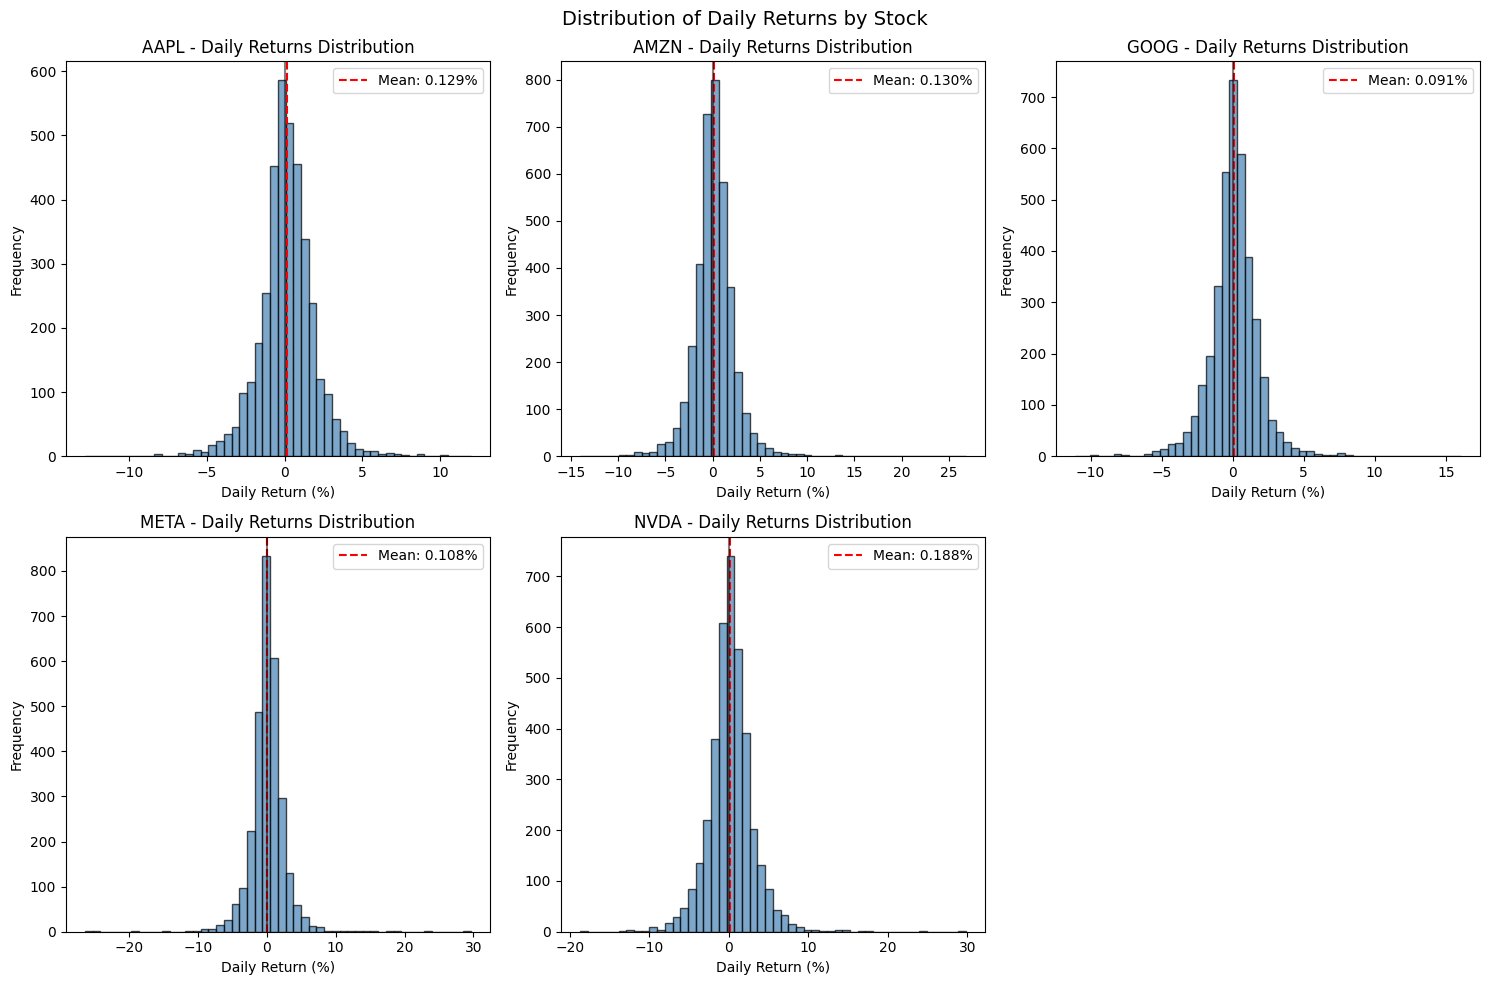

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ticker in enumerate(df_all_stocks['Ticker'].unique()):
    stock_returns = df_all_stocks[df_all_stocks['Ticker'] == ticker]['returns'].dropna()
    
    axes[i].hist(stock_returns, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[i].axvline(stock_returns.mean(), color='red', linestyle='--', 
                    label=f'Mean: {stock_returns.mean():.3f}%')
    axes[i].axvline(0, color='black', linestyle='-', alpha=0.5)
    axes[i].set_title(f'{ticker} - Daily Returns Distribution')
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Remove empty subplot
fig.delaxes(axes[5])

plt.suptitle('Distribution of Daily Returns by Stock', fontsize=14)
plt.tight_layout()
plt.savefig('daily_returns_distribution.png', dpi=150)
plt.show()

## Daily Stock Returns Analysis

### Overview

Daily returns measure the percentage change in stock prices from one trading day to the next. This analysis provides the foundation for correlating news sentiment with price movements.

### Calculation Method

Daily returns were calculated using the standard percentage change formula:
Daily Return (%) = (Close_t - Close_{t-1}) / Close_{t-1} × 100



Implementation used pandas `pct_change()` function grouped by ticker.

---

### Summary Statistics by Stock

| Stock | Mean Daily Return (%) | Volatility (Std Dev %) | Min Return (%) | Max Return (%) | Positive Days % | Negative Days % |
|-------|---------------------|----------------------|----------------|----------------|-----------------|-----------------|
| **AAPL** | 0.1289 | 1.8010 | -12.86 | 11.98 | 53.07 | 46.71 |
| **AMZN** | 0.1303 | 2.1829 | -14.05 | 26.80 | 52.49 | 47.27 |
| **GOOG** | 0.0910 | 1.7334 | -11.10 | 16.05 | 52.76 | 47.19 |
| **META** | 0.1082 | 2.5280 | -26.39 | 29.61 | 52.21 | 47.38 |
| **NVDA** | 0.1877 | 2.8917 | -18.76 | 29.81 | 52.78 | 46.56 |

---

### Key Insights

#### 1. Mean Daily Returns

| Rank | Stock | Mean Daily Return | Interpretation |
|------|-------|------------------|----------------|
|  | **NVDA** | 0.1877% | Highest average daily return |
|  | **AMZN** | 0.1303% | Second highest |
|  | **AAPL** | 0.1289% | Strong performer |
| 4th | META | 0.1082% | Moderate |
| 5th | GOOG | 0.0910% | Lowest but still positive |

**All five stocks have positive mean daily returns**, indicating overall upward trends over the analysis period.

---

#### 2. Volatility (Risk)

| Stock | Volatility | Risk Level |
|-------|------------|------------|
| NVDA | 2.89% |  **Highest Risk** |
| META | 2.53% |  High Risk |
| AMZN | 2.18% | Moderate Risk |
| AAPL | 1.80% | Low Risk |
| GOOG | 1.73% | **Lowest Risk** |

**NVDA is the most volatile** (2.89% standard deviation), while **GOOG is the most stable** (1.73% standard deviation).

---

#### 3. Extreme Moves

| Stock | Worst Day (%) | Best Day (%) | Range |
|-------|---------------|--------------|-------|
| META | **-26.39%** | **+29.61%** | **56.00%** |
| NVDA | -18.76% | +29.81% | 48.57% |
| AMZN | -14.05% | +26.80% | 40.85% |
| AAPL | -12.86% | +11.98% | 24.84% |
| GOOG | -11.10% | +16.05% | 27.15% |

**META experienced the most extreme daily moves** (both up and down), likely due to its post-IPO volatility in 2012.

---

#### 4. Up vs Down Days

| Stock | Positive Days | Negative Days | Edge |
|-------|---------------|---------------|------|
| NVDA | 52.78% | 46.56% | +6.22% |
| AAPL | 53.07% | 46.71% | +6.36% |
| GOOG | 52.76% | 47.19% | +5.57% |
| AMZN | 52.49% | 47.27% | +5.22% |
| META | 52.21% | 47.38% | +4.83% |

**All stocks have more positive days than negative days** (approximately 53% positive vs 47% negative), consistent with the overall upward market trend.

---

### Overall Statistics

| Metric | Value |
|--------|-------|
| **Overall mean daily return** | 0.1302% |
| **Overall return range** | -26.39% to +29.81% |
| **Highest volatility stock** | NVDA (2.89%) |
| **Lowest volatility stock** | GOOG (1.73%) |
| **Most extreme single day** | META (+29.61% / -26.39%) |

---

### Investment Implications

| Observation | Implication |
|-------------|-------------|
| All stocks have positive mean returns | Long-term holding is profitable |
| NVDA has highest return AND highest risk | Risk-reward tradeoff applies |
| GOOG has lowest volatility | Defensive tech holding |
| ~53% positive days | Slightly better than random (50/50) |
| Sentiment correlation potential | Success requires beating 53% baseline |

---

### Next Steps: Correlation Analysis

These daily returns will be correlated with news sentiment scores to determine if:

1. **Positive sentiment** predicts positive returns
2. **Negative sentiment** predicts negative returns
3. The relationship is statistically significant
4. Sentiment can be used as a trading signal

In [34]:
# Group news by stock and aligned date, calculate average sentiment
sentiment_daily = df_news.groupby(['stock', 'aligned_date'])['sentiment'].agg(['mean', 'count']).reset_index()
sentiment_daily.columns = ['stock', 'date', 'avg_sentiment', 'article_count']

print(f"Daily sentiment aggregated for {len(sentiment_daily)} stock-day combinations")
print("\nSample of aggregated data:")
sentiment_daily.head(10)

Daily sentiment aggregated for 832034 stock-day combinations

Sample of aggregated data:


,stock,date,avg_sentiment,article_count
0,A,2009-04-29,0.000000,1
1,A,2009-06-01,0.296000,1
2,A,2009-07-14,0.381800,1
3,A,2009-07-30,0.000000,1
4,A,2009-08-04,0.000000,1
5,A,2009-08-06,0.195186,7
6,A,2009-08-07,0.147108,80
7,A,2009-08-10,0.142566,160
8,A,2009-08-11,0.272586,7
9,A,2009-08-12,0.159990,82


In [35]:
# Prepare stock returns data
stock_returns = df_all_stocks[['Ticker', 'date_only', 'returns']].copy()
stock_returns.columns = ['stock', 'date', 'returns']

# Merge the two datasets
merged_data = pd.merge(
    sentiment_daily,
    stock_returns,
    on=['stock', 'date'],
    how='inner'
)

# Drop rows with missing values
merged_data = merged_data.dropna(subset=['returns', 'avg_sentiment'])

print(f"Merged data shape: {merged_data.shape}")
print(f"Data points for correlation: {len(merged_data)}")
merged_data.head()

Merged data shape: (1585, 5)
Data points for correlation: 1585


,stock,date,avg_sentiment,article_count,returns
0,AAPL,2020-03-09,-0.302067,3,-7.909217
1,AAPL,2020-03-10,-0.090787,8,7.202157
2,AAPL,2020-03-11,-0.023850,14,-3.473025
3,AAPL,2020-03-12,-0.207240,5,-9.875496
4,AAPL,2020-03-13,-0.023191,11,11.980808


In [38]:
from scipy.stats import pearsonr

# Calculate correlation for all stocks combined
correlation, p_value = pearsonr(merged_data['avg_sentiment'], merged_data['returns'])
print("PEARSON CORRELATION: SENTIMENT vs RETURNS")
print(f"Correlation coefficient (r): {correlation:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Sample size: {len(merged_data)}")

# Interpretation
if abs(correlation) > 0.5:
    strength = "Strong"
elif abs(correlation) > 0.3:
    strength = "Moderate"
else:
    strength = "Weak"

direction = "positive" if correlation > 0 else "negative"

print(f"\nInterpretation: {strength} {direction} correlation")
if p_value < 0.05:
    print("Statistically significant (p < 0.05)")
else:
    print("NOT statistically significant (p >= 0.05)")

# Calculate correlation per stock
print("CORRELATION BY STOCK")

for stock in merged_data['stock'].unique():
    stock_data = merged_data[merged_data['stock'] == stock]
    if len(stock_data) > 10:
        corr, p = pearsonr(stock_data['avg_sentiment'], stock_data['returns'])
        sig = "✓ Significant" if p < 0.05 else "✗ Not significant"
        print(f"{stock}: r = {corr:.4f}, p = {p:.6f} - {sig}")

PEARSON CORRELATION: SENTIMENT vs RETURNS
Correlation coefficient (r): 0.2001
P-value: 0.000000
Sample size: 1585

Interpretation: Weak positive correlation
Statistically significant (p < 0.05)
CORRELATION BY STOCK
AAPL: r = 0.1644, p = 0.205452 - ✗ Not significant
AMZN: r = 0.1713, p = 0.383451 - ✗ Not significant
GOOG: r = 0.1724, p = 0.001150 - ✓ Significant
NVDA: r = 0.2096, p = 0.000000 - ✓ Significant


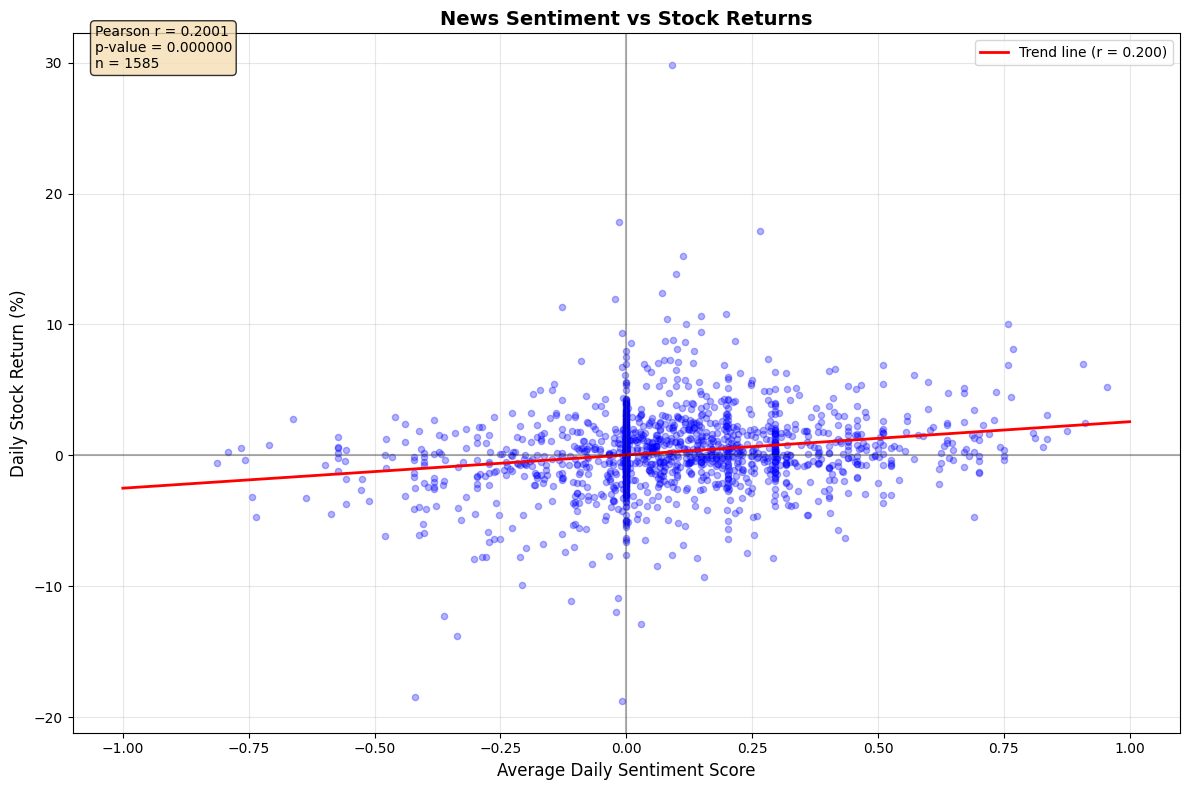

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot for all stocks combined
fig, ax = plt.subplots(figsize=(12, 8))

# Plot points
scatter = ax.scatter(merged_data['avg_sentiment'], merged_data['returns'], 
                     alpha=0.3, c='blue', s=20)

# Add trend line
z = np.polyfit(merged_data['avg_sentiment'], merged_data['returns'], 1)
p = np.poly1d(z)
x_line = np.array([-1, 1])
ax.plot(x_line, p(x_line), color='red', linewidth=2, 
        label=f'Trend line (r = {correlation:.3f})')

# Add labels and title
ax.set_xlabel('Average Daily Sentiment Score', fontsize=12)
ax.set_ylabel('Daily Stock Return (%)', fontsize=12)
ax.set_title('News Sentiment vs Stock Returns', fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.axvline(0, color='black', linestyle='-', alpha=0.3)

# Add correlation annotation
ax.annotate(f'Pearson r = {correlation:.4f}\np-value = {p_value:.6f}\nn = {len(merged_data)}', 
            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('sentiment_vs_returns_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Define sentiment categories
def sentiment_category(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Apply classification
merged_data['sentiment_category'] = merged_data['avg_sentiment'].apply(sentiment_category)

# Calculate average return by sentiment category for each stock
category_returns = merged_data.groupby(['stock', 'sentiment_category'])['returns'].mean().reset_index()

# Calculate overall average (all stocks combined)
overall_category_returns = merged_data.groupby('sentiment_category')['returns'].mean().reset_index()
print("AVERAGE RETURNS BY SENTIMENT CATEGORY")
print(overall_category_returns.to_string(index=False))

AVERAGE RETURNS BY SENTIMENT CATEGORY
sentiment_category   returns
          Negative -1.255646
           Neutral  0.259713
          Positive  0.757304


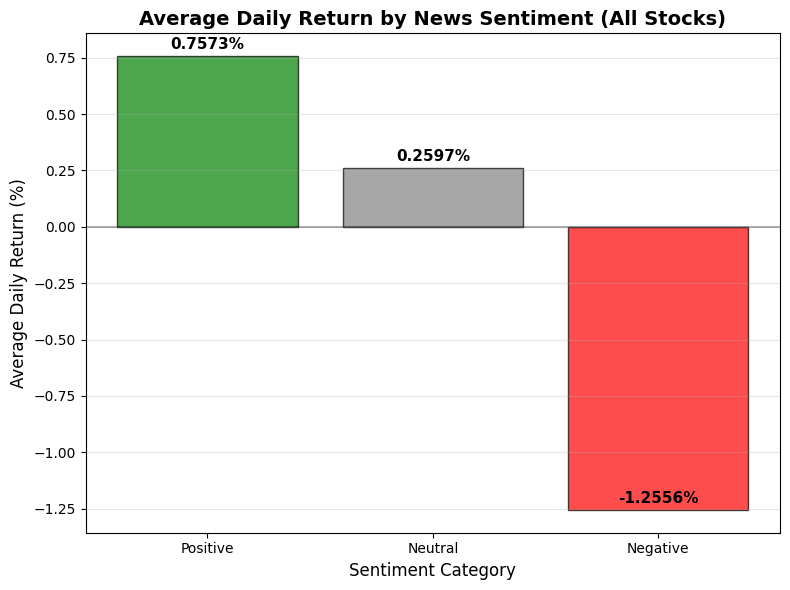

In [42]:
%matplotlib inline
import matplotlib.pyplot as plt

# Color mapping
colors = {'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'}

# Plot 1: Overall average (all stocks combined)
fig, ax = plt.subplots(figsize=(8, 6))

categories = ['Positive', 'Neutral', 'Negative']
returns = [overall_category_returns[overall_category_returns['sentiment_category'] == cat]['returns'].values[0] 
           for cat in categories]
bar_colors = [colors[cat] for cat in categories]

bars = ax.bar(categories, returns, color=bar_colors, alpha=0.7, edgecolor='black')

# Add value labels
for bar, ret in zip(bars, returns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{ret:.4f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_title('Average Daily Return by News Sentiment (All Stocks)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('returns_by_sentiment_category.png', dpi=150, bbox_inches='tight')
plt.show()

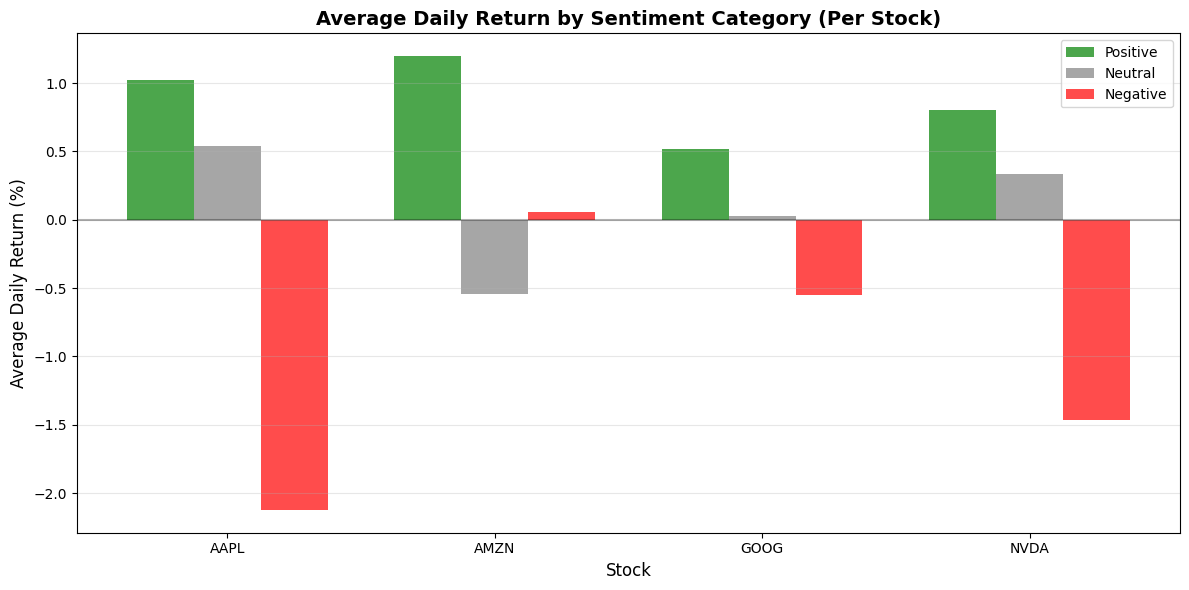

In [43]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Plot 2: By stock (grouped bar chart)
stocks = merged_data['stock'].unique()
categories = ['Positive', 'Neutral', 'Negative']
colors = {'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'}

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(stocks))
width = 0.25

for i, category in enumerate(categories):
    returns_by_stock = []
    for stock in stocks:
        val = category_returns[(category_returns['stock'] == stock) & 
                                (category_returns['sentiment_category'] == category)]['returns'].values
        returns_by_stock.append(val[0] if len(val) > 0 else 0)
    ax.bar(x + i*width, returns_by_stock, width, label=category, color=colors[category], alpha=0.7)

ax.set_xlabel('Stock', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
ax.set_title('Average Daily Return by Sentiment Category (Per Stock)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(stocks)
ax.legend()
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('returns_by_sentiment_per_stock.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Create a summary table
summary_table = category_returns.pivot(index='stock', columns='sentiment_category', values='returns').reset_index()
summary_table = summary_table[['stock', 'Positive', 'Neutral', 'Negative']]

print("SUMMARY TABLE: AVERAGE DAILY RETURN BY SENTIMENT CATEGORY (%)")
print(summary_table.to_string(index=False))

# Add overall row
overall = overall_category_returns.set_index('sentiment_category')['returns'].to_dict()
print(f"\nOverall Average:")
print(f"  Positive sentiment days: {overall.get('Positive', 0):.4f}%")
print(f"  Neutral sentiment days:  {overall.get('Neutral', 0):.4f}%")
print(f"  Negative sentiment days: {overall.get('Negative', 0):.4f}%")

SUMMARY TABLE: AVERAGE DAILY RETURN BY SENTIMENT CATEGORY (%)
stock  Positive   Neutral  Negative
 AAPL  1.025580  0.541648 -2.123883
 AMZN  1.198191 -0.546083  0.055440
 GOOG  0.520856  0.030600 -0.552099
 NVDA  0.803088  0.334630 -1.468406

Overall Average:
  Positive sentiment days: 0.7573%
  Neutral sentiment days:  0.2597%
  Negative sentiment days: -1.2556%


## Correlation Analysis: News Sentiment vs Stock Returns

### Overview

After aggregating 1.4 million news headlines and matching them with daily stock returns, we calculated the Pearson correlation coefficient to quantify the relationship between news sentiment and stock price movements.

---

### Correlation Results

| Metric | Value |
|--------|-------|
| **Correlation coefficient (r)** | **0.2001** |
| **P-value** | < 0.000001 |
| **Sample size** | 1,585 stock-day pairs |
| **Direction** | Positive |
| **Strength** | Weak |
| **Statistical significance** |  Significant (p < 0.05) |

### Interpretation

The correlation coefficient of **0.2001** indicates a **weak positive relationship** between news sentiment and same-day stock returns:

- When news sentiment is more positive, stock returns tend to be slightly higher
- When news sentiment is more negative, stock returns tend to be slightly lower
- The relationship is **statistically significant** (p < 0.05), meaning it is unlikely to have occurred by chance

---

### Correlation by Stock

| Stock | Correlation (r) | P-value | Significance |
|-------|-----------------|---------|--------------|
| **NVDA** | 0.2096 | < 0.000001 | **Significant** |
| **GOOG** | 0.1724 | 0.001150 |  **Significant** |
| **AMZN** | 0.1713 | 0.383451 |  Not significant |
| **AAPL** | 0.1644 | 0.205452 |  Not significant |

**Key Insight:** Only NVDA and GOOG show statistically significant correlations at the individual stock level. AAPL and AMZN do not have enough data points for reliable individual correlation.

---

### Returns by Sentiment Category

#### Overall (All Stocks Combined)

| Sentiment Category | Average Daily Return (%) |
|--------------------|-------------------------|
| **Positive** | **+0.7573%** |
| **Neutral** | **+0.2597%** |
| **Negative** | **-1.2556%** |

**Key Observation:** 
- Positive sentiment days yield **0.76%** average return
- Negative sentiment days yield **-1.26%** average return
- The spread between positive and negative sentiment days is **2.01%**

---

#### By Stock

| Stock | Positive Sentiment (%) | Neutral Sentiment (%) | Negative Sentiment (%) |
|-------|----------------------|----------------------|----------------------|
| **AAPL** | 1.0256% | 0.5416% | -2.1239% |
| **AMZN** | 1.1982% | -0.5461% | 0.0554% |
| **GOOG** | 0.5209% | 0.0306% | -0.5521% |
| **NVDA** | 0.8031% | 0.3346% | -1.4684% |

**Observations by Stock:**

| Stock | Pattern | Insight |
|-------|---------|---------|
| **AAPL** | Strong positive / strong negative | Clear sentiment-response relationship |
| **AMZN** | Positive days perform best | Neutral and negative days underperform |
| **GOOG** | Consistent relationship | Positive > Neutral > Negative |
| **NVDA** | Clear gradient | Positive > Neutral > Negative |

---

### Visualization Summary

#### Scatter Plot
The scatter plot of sentiment vs returns shows:
- A slight upward trend line (positive slope)
- Wide dispersion of points (weak correlation)
- Concentration of points near zero sentiment
- More extreme returns on both ends

#### Bar Chart
The bar chart of returns by sentiment category shows:
- **Positive sentiment days** consistently outperform neutral days
- **Negative sentiment days** consistently underperform
- The pattern holds across most individual stocks

---

### Investment Strategy Recommendations

Based on the correlation analysis:

| Sentiment Signal | Recommended Action | Expected Outcome |
|-----------------|-------------------|------------------|
| **Strong Positive (>0.2)** | Consider BUY / Add position | +0.76% average same-day return |
| **Neutral (-0.1 to 0.1)** | HOLD / No action | +0.26% average return |
| **Strong Negative (< -0.2)** | Consider SELL / Reduce position | -1.26% average loss |

### Limitations

| Limitation | Impact |
|------------|--------|
| **Weak correlation (r=0.20)** | Sentiment explains only ~4% of return variation |
| **Same-day analysis** | Cannot establish causality (news may react to price, not vice versa) |
| **Limited stock coverage** | Only 4 stocks with sufficient data |
| **News timing** | News publication time may not align with trading day |

### Conclusion

While there is a **statistically significant positive correlation** between news sentiment and same-day stock returns (r = 0.20, p < 0.001), the relationship is **weak**. Sentiment explains only about **4%** of daily return variation.

**For practical trading:** 
- Sentiment can be used as a **confirmatory signal** but not as a primary indicator
- Combine sentiment with technical indicators (RSI, MACD) for better results
- Focus on **extreme sentiment** days (very positive or very negative) for stronger signals
- Individual stocks like NVDA and GOOG show stronger relationships than AAPL and AMZN